In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [5]:
# 2. DATASET PATH
# ============================================================

DATASET_PATH = "/content/drive/MyDrive/Dataset"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 50
SEED = 42

In [6]:
# 3. LOAD DATASET AND CREATE DATAFRAME
# ============================================================

filepaths = []
labels = []

for folder in os.listdir(DATASET_PATH):
    folder_path = os.path.join(DATASET_PATH, folder)

    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file)
            filepaths.append(file_path)
            labels.append(folder)


In [7]:
# Create DataFrame

df = pd.DataFrame({
    "filepaths": filepaths,
    "labels": labels
})

print("Total Images:", len(df))
print(df.head())


Total Images: 7740
                                           filepaths               labels
0  /content/drive/MyDrive/Dataset/Tomato__Target_...  Tomato__Target_Spot
1  /content/drive/MyDrive/Dataset/Tomato__Target_...  Tomato__Target_Spot
2  /content/drive/MyDrive/Dataset/Tomato__Target_...  Tomato__Target_Spot
3  /content/drive/MyDrive/Dataset/Tomato__Target_...  Tomato__Target_Spot
4  /content/drive/MyDrive/Dataset/Tomato__Target_...  Tomato__Target_Spot


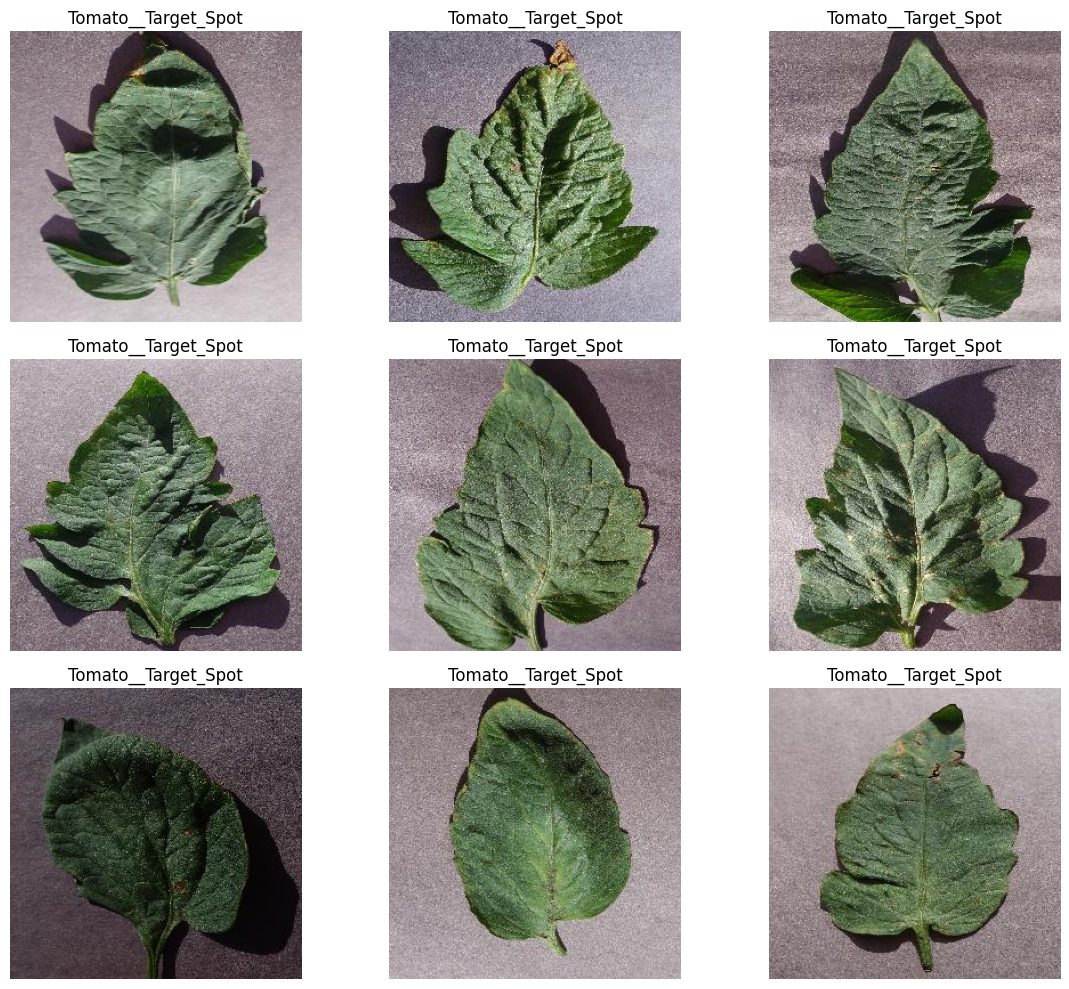

In [8]:
# 4. VISUALIZE SAMPLE IMAGES
# ============================================================

def show_samples(dataframe, num_images=9):
    plt.figure(figsize=(12, 10))

    for i in range(min(num_images, len(dataframe))):
        plt.subplot(3, 3, i + 1)

        img = cv2.imread(dataframe.iloc[i]["filepaths"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.imshow(img)
        plt.title(dataframe.iloc[i]["labels"])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_samples(df)

In [9]:
# 5. TRAIN / VALIDATION / TEST SPLIT
# Example: 70% train, 15% validation, 15% test
# ============================================================

train_df, temp_df = train_test_split(
    df,
    train_size=0.7,
    random_state=SEED,
    stratify=df["labels"]
)

val_df, test_df = train_test_split(
    temp_df,
    train_size=0.5,
    random_state=SEED,
    stratify=temp_df["labels"]
)

print("Train Size:", len(train_df))
print("Validation Size:", len(val_df))
print("Test Size:", len(test_df))

Train Size: 5418
Validation Size: 1161
Test Size: 1161


In [10]:
# 6. DATA PREPROCESSING + AUGMENTATION
# ============================================================

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_test_gen = ImageDataGenerator(
    rescale=1./255
)

train_data = train_gen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepaths",
    y_col="labels",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
    )

val_data = val_test_gen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepaths",
    y_col="labels",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_data = val_test_gen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepaths",
    y_col="labels",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)


Found 5417 validated image filenames belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 1 invalid image filename(s) in x_col="filepaths". These filename(s) will be ignored.
  warnings.warn(


Found 1161 validated image filenames belonging to 4 classes.
Found 1161 validated image filenames belonging to 4 classes.


In [11]:
# 7. BUILD MODEL (TRANSFER LEARNING - VGG16)
# ============================================================

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model
base_model.trainable = False

x = base_model.output
x = Flatten()(x)
x = Dropout(0.3)(x)
output = Dense(
    len(train_data.class_indices),
    activation="softmax"
)(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │       100,356 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,815,044 (56.51 MB)

 Trainable params: 100,356 (392.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [12]:
# 8. CALLBACKS
# ============================================================

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "best_model.h5",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]


In [13]:
# 9. TRAINING MODEL
# ============================================================

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    verbose=1
)

Epoch 1/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 1776s 5s/step - accuracy: 0.7979 - loss: 0.5661 - val_accuracy: 0.8501 - val_loss: 0.4549
Epoch 2/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 99s 291ms/step - accuracy: 0.8621 - loss: 0.4142 - val_accuracy: 0.9104 - val_loss: 0.2523
Epoch 3/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 98s 288ms/step - accuracy: 0.8806 - loss: 0.3689 - val_accuracy: 0.8975 - val_loss: 0.3054
Epoch 4/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 98s 288ms/step - accuracy: 0.8879 - loss: 0.3507 - val_accuracy: 0.9130 - val_loss: 0.2551
Epoch 5/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 98s 289ms/step - accuracy: 0.8905 - loss: 0.3364 - val_accuracy: 0.9371 - val_loss: 0.1696
Epoch 6/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 100s 294ms/step - accuracy: 0.8876 - loss: 0.3953 - val_accuracy: 0.9096 - val_loss: 0.2967
Epoch 7/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 101s 296ms/step - accuracy: 0.9071 - loss: 0.3073 - val_accuracy: 0.9440 - val_loss: 0.1511
Epoch 8/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 101s 297ms/step - accuracy: 0.8981 - loss:

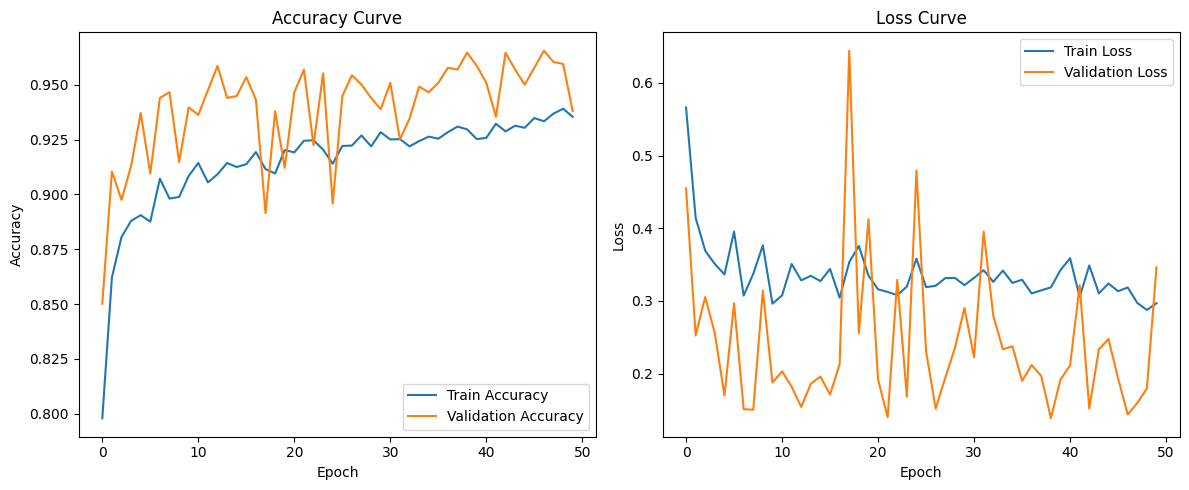

In [14]:
# 10. VISUALIZE LOSS CURVES
# ============================================================

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
# 11. MODEL EVALUATION
# ============================================================

pred_probs = model.predict(test_data)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = test_data.classes
class_names = list(test_data.class_indices.keys())

accuracy = accuracy_score(true_classes, pred_classes)
error_rate = 1 - accuracy

print("\nAccuracy:", accuracy)
print("Error Rate:", error_rate)

print("\nClassification Report:\n")
print(classification_report(true_classes, pred_classes, target_names=class_names))


73/73 ━━━━━━━━━━━━━━━━━━━━ 298s 4s/step

Accuracy: 0.9310938845822567
Error Rate: 0.06890611541774327

Classification Report:

                                       precision    recall  f1-score   support

                Tomato_Bacterial_spot       0.97      0.96      0.96       319
                  Tomato_Early_blight       0.97      0.67      0.80       150
                  Tomato__Target_Spot       0.77      1.00      0.87       211
Tomato__Tomato_YellowLeaf__Curl_Virus       1.00      0.97      0.98       481

                             accuracy                           0.93      1161
                            macro avg       0.92      0.90      0.90      1161
                         weighted avg       0.94      0.93      0.93      1161



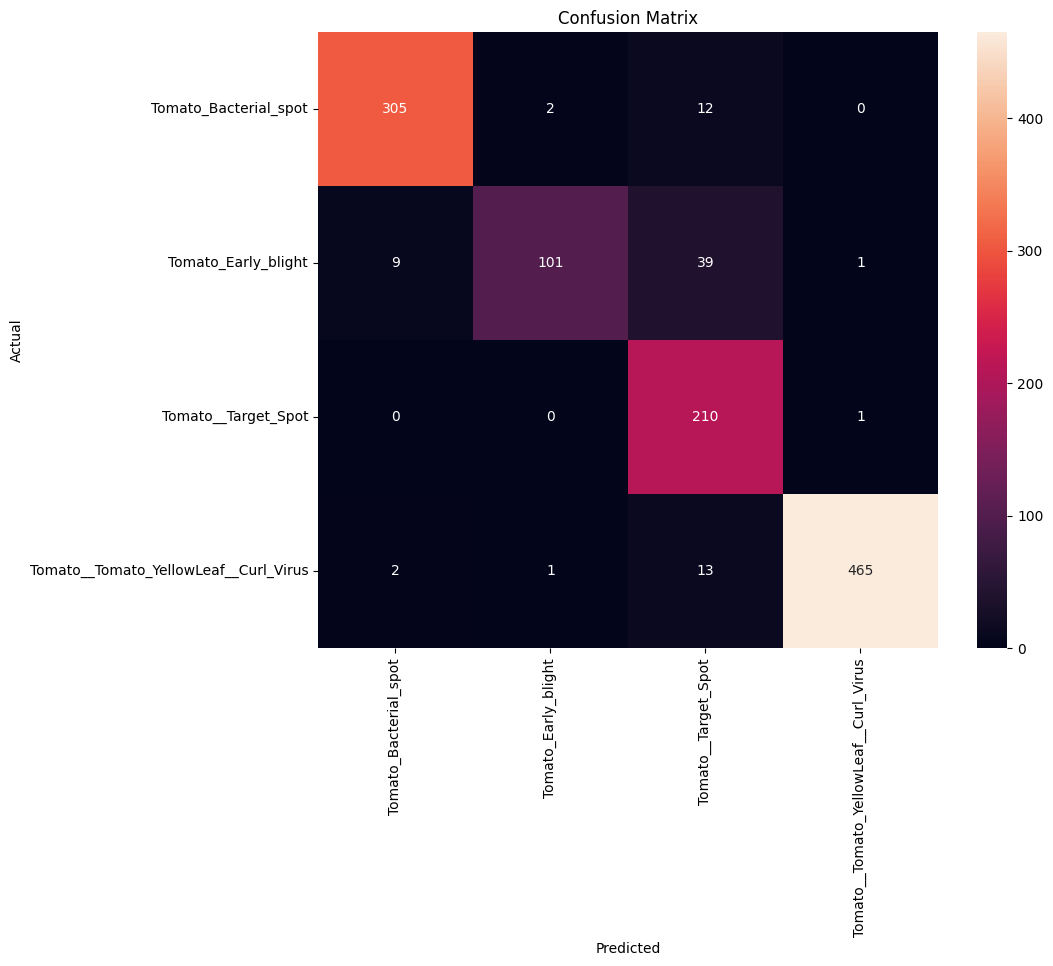

In [16]:
# 12. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


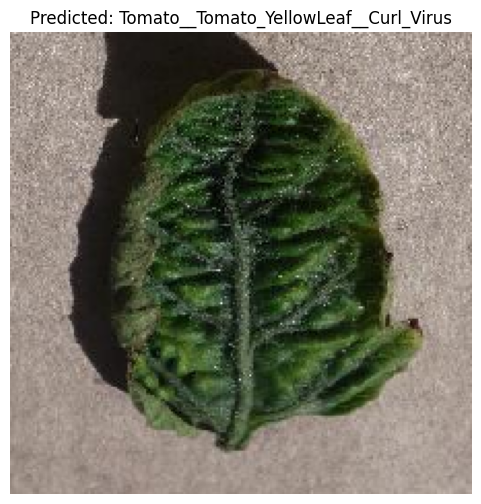

In [17]:
# 13. PREDICTION ON SINGLE TEST IMAGE
# ============================================================

sample_index = 5
sample_path = test_df.iloc[sample_index]["filepaths"]

img = tf.keras.preprocessing.image.load_img(sample_path, target_size=IMG_SIZE)
img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
predicted_class = class_names[np.argmax(prediction)]

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Predicted: {predicted_class}")
plt.axis("off")
plt.show()


In [18]:
model.save("final_corn_leaf_model.h5")
print("\nModel successfully saved.")


Model successfully saved.
